# How to Achieve Success by Streaming on Twitch​

By: Annette Martin​, Semen Petrov​, Kunanon Chaojaroenrat​, Ismail Cem Bayramoglu​

## Define success​:

* 7-day follower growth is our main definition of success.

  * Absolute growth:
    * ΔFollowers_7d = Followers(t) − Followers(t−7)
  * Relative growth:
    * GrowthRate_7d = ΔFollowers_7d / max(Followers(t−7), 1)

  * We use follower growth because it is measurable for any channel using public follower totals with repeated snapshots. We use a 7-day window due to the project deadline while preserving the same logic as longer-term growth.

* Secondary Success Indicators (Support Metrics):

    * These metrics support interpretation and recommendations (they are not the main success label unless explicitly modeled):

      * Audience size proxy: rolling average live viewers (requires repeated sampling; a single snapshot is not an average)

      * Content performance proxy: VOD views per minute/hour from recent videos

      * Consistency and activity: streams/videos in last 7 days, days active in last 7 days, average stream duration, and duration variability

 ## Stakeholders and Decisions

* Streamer: chooses content/category and streaming schedule to maximize 7-day follower growth.

* Administrator: analyzes past performance and game trends, then recommends which games/categories and schedule changes are most likely to increase viewers and growth.

* Moderator: manages chat and engagement (welcome raiders/new viewers, enforce rules, handle bans/timeouts) to improve retention and community quality.

* Sponsor: selects streamers to support based on measurable growth and engagement proxies (7-day growth, viewer/VOD performance, consistency).

# Kaggle data

In [1]:
# Imports (Kaggle + Twitch)
import os
import time
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from tqdm import tqdm

import kagglehub

from datetime import datetime, timezone, timedelta


In [2]:
# Define datasets (Kaggle)
datasets = {
    "streamers": "aayushmishra1512/twitchdata",
    "top_games": "rankirsh/evolution-of-top-games-on-twitch"
}

dfs = {}
encodings_to_try = ["utf-8", "latin-1", "cp1252", "iso-8859-1"]

for dataset_name, kaggle_path in datasets.items():
    folder_path = kagglehub.dataset_download(kaggle_path)
    print(f"\nDownloaded: {dataset_name} -> {folder_path}")

    for fname in os.listdir(folder_path):
        full_path = os.path.join(folder_path, fname)
        if not os.path.isfile(full_path):
            continue

        base, ext = os.path.splitext(fname)
        ext = ext.lower()

        try:
            if ext == ".csv":
                df = None
                for enc in encodings_to_try:
                    try:
                        df = pd.read_csv(full_path, encoding=enc)
                        break
                    except UnicodeDecodeError:
                        continue
                if df is None:
                    print(f"⚠️ Could not decode CSV: {fname}")
                    continue

            elif ext in [".xlsx", ".xls"]:
                df = pd.read_excel(full_path)

            else:
                continue  # skip non-tabular files

            key = f"{dataset_name}_{base}"
            if key in dfs:
                key = f"{key}_{len(dfs)}"

            dfs[key] = df
            print(f"✓ Loaded {key}: {df.shape[0]} rows × {df.shape[1]} cols")

        except Exception as e:
            print(f"✗ Error loading {fname}: {e}")

print(f"\nTotal tables loaded: {len(dfs)}")


100%|██████████| 36.5k/36.5k [00:00<00:00, 8.33MB/s]

Extracting files...

Downloaded: streamers -> /root/.cache/kagglehub/datasets/aayushmishra1512/twitchdata/versions/3
✓ Loaded streamers_twitchdata-update: 1000 rows × 11 cols


100%|██████████| 605k/605k [00:00<00:00, 47.7MB/s]

Extracting files...

Downloaded: top_games -> /root/.cache/kagglehub/datasets/rankirsh/evolution-of-top-games-on-twitch/versions/17
✓ Loaded top_games_Twitch_global_data: 105 rows × 9 cols
✓ Loaded top_games_Twitch_game_data: 21000 rows × 12 cols

Total tables loaded: 3


In [3]:
for k in dfs.keys():
    print(k)

streamers_twitchdata-update
top_games_Twitch_global_data
top_games_Twitch_game_data


In [4]:
display(dfs["streamers_twitchdata-update"].head())
display(dfs["top_games_Twitch_global_data"].head())
display(dfs["top_games_Twitch_game_data"].head())

,Channel,Watch time(Minutes),Stream time(minutes),Peak viewers,Average viewers,Followers,Followers gained,Views gained,Partnered,Mature,Language
0,xQcOW,6196161750,215250,222720,27716,3246298,1734810,93036735,True,False,English
1,summit1g,6091677300,211845,310998,25610,5310163,1370184,89705964,True,False,English
2,Gaules,5644590915,515280,387315,10976,1767635,1023779,102611607,True,True,Portuguese
3,ESL_CSGO,3970318140,517740,300575,7714,3944850,703986,106546942,True,False,English
4,Tfue,3671000070,123660,285644,29602,8938903,2068424,78998587,True,False,English


,year,Month,Hours_watched,Avg_viewers,Peak_viewers,Streams,Avg_channels,Games_streamed,Viewer_ratio
0,2016,1,480241904,646355,1275257,7701675,20076,12149,29.08
1,2016,2,441859897,635769,1308032,7038520,20427,12134,28.98
2,2016,3,490669308,660389,1591551,7390957,20271,12234,28.92
3,2016,4,377975447,525696,1775120,6869719,16791,12282,28.80
4,2016,5,449836631,605432,1438962,7535519,19394,12424,28.85


,Rank,Game,Month,Year,Hours_watched,Hours_streamed,Peak_viewers,Peak_channels,Streamers,Avg_viewers,Avg_channels,Avg_viewer_ratio
0,1,League of Legends,1,2016,94377226,1362044,530270,2903,129172,127021,1833,69.29
1,2,Counter-Strike: Global Offensive,1,2016,47832863,830105,372654,2197,120849,64378,1117,57.62
2,3,Dota 2,1,2016,45185893,433397,315083,1100,44074,60815,583,104.26
3,4,Hearthstone,1,2016,39936159,235903,131357,517,36170,53749,317,169.29
4,5,Call of Duty: Black Ops III,1,2016,16153057,1151578,71639,3620,214054,21740,1549,14.03


# Analysis

In [5]:
top10 = dfs["top_games_Twitch_game_data"].query("Rank <= 10")

game_counts_df = (
    top10.groupby("Game", as_index=False)
        .size()
        .rename(columns={"size": "top10_months"})
        .query("top10_months >= 10")
        .sort_values("top10_months", ascending=False)
)

print(f"Games appearing in monthly Top 10 for >=10 months: {len(game_counts_df)}")
display(game_counts_df.head(20))


Games appearing in monthly Top 10 for >=10 months: 16


,Game,top10_months
51,League of Legends,105
23,Dota 2,90
16,Counter-Strike: Global Offensive,87
43,Fortnite,81
45,Grand Theft Auto V,79
50,Just Chatting,72
85,World of Warcraft,62
53,Minecraft,58
83,VALORANT,50
46,Hearthstone,45


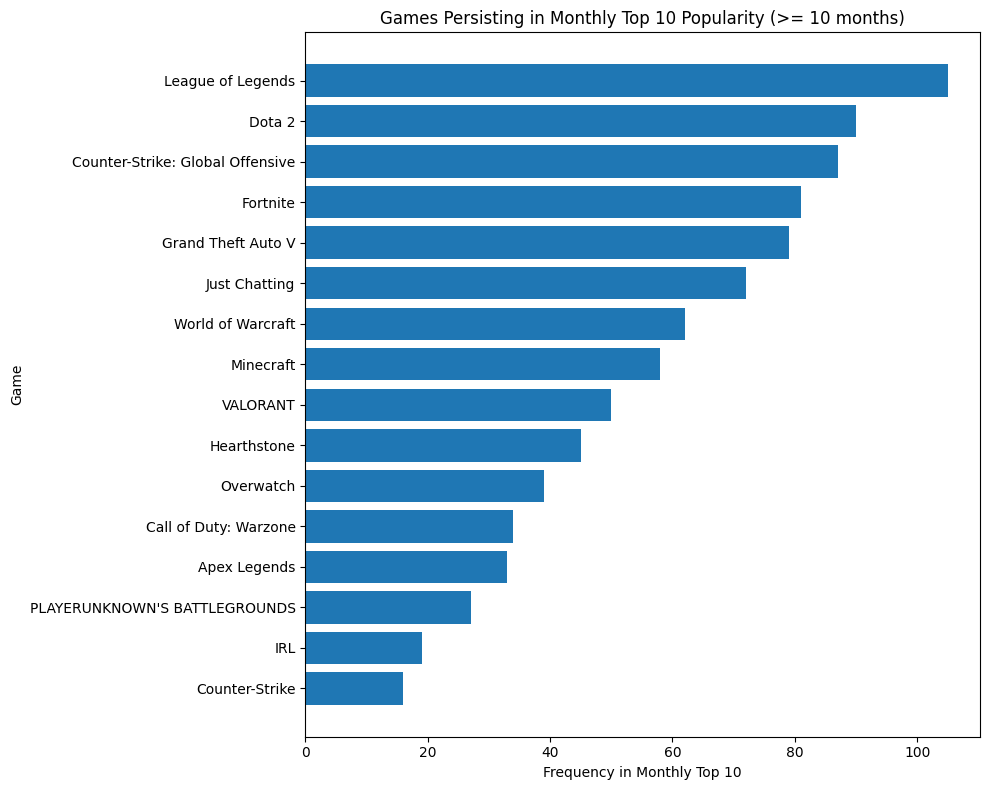

In [6]:
# Plot: how often games appear in monthly Top 10 (persistent games)
plot_df = game_counts_df.sort_values("top10_months", ascending=False)

plt.figure(figsize=(10, 8))  # better for ~16 games
plt.barh(plot_df["Game"], plot_df["top10_months"])
plt.gca().invert_yaxis()

plt.ylabel("Game")
plt.xlabel("Frequency in Monthly Top 10")
plt.title("Games Persisting in Monthly Top 10 Popularity (>= 10 months)")
plt.tight_layout()
plt.show()



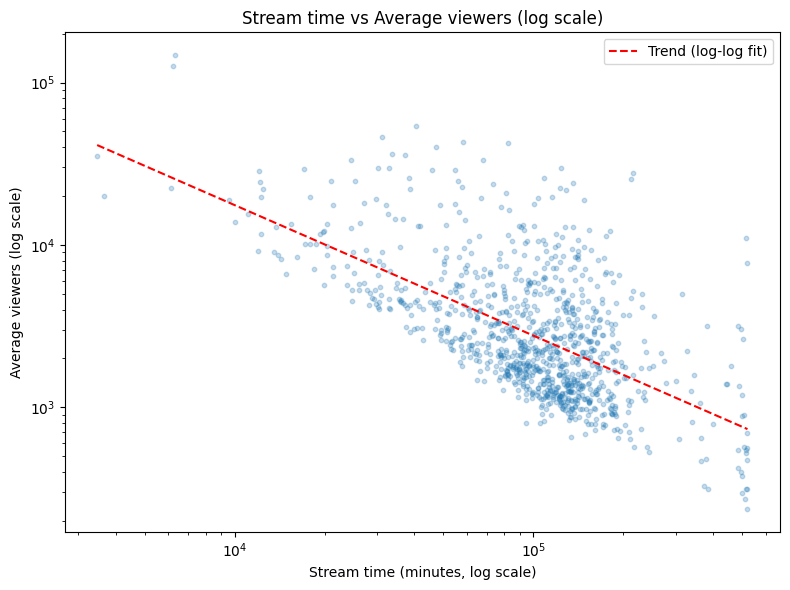

In [7]:
df = dfs["streamers_twitchdata-update"].copy()

# Convert to numeric and drop missing/invalid rows
x = pd.to_numeric(df["Stream time(minutes)"], errors="coerce")
y = pd.to_numeric(df["Average viewers"], errors="coerce")
df_xy = pd.DataFrame({"stream_time_min": x, "avg_viewers": y}).dropna()
df_xy = df_xy[(df_xy["stream_time_min"] > 0) & (df_xy["avg_viewers"] > 0)]

# Fit a trend line in log-log space (handles skew better)
lx = np.log10(df_xy["stream_time_min"])
ly = np.log10(df_xy["avg_viewers"])
m, b = np.polyfit(lx, ly, 1)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(df_xy["stream_time_min"], df_xy["avg_viewers"], alpha=0.25, s=10)

# Trend line (convert back to original scale)
x_line = np.linspace(df_xy["stream_time_min"].min(), df_xy["stream_time_min"].max(), 200)
y_line = 10 ** (m * np.log10(x_line) + b)
plt.plot(x_line, y_line, "r--", label="Trend (log-log fit)")

# Use log scales so outliers don’t ruin the chart
plt.xscale("log")
plt.yscale("log")

plt.title("Stream time vs Average viewers (log scale)")
plt.xlabel("Stream time (minutes, log scale)")
plt.ylabel("Average viewers (log scale)")
plt.legend()
plt.tight_layout()
plt.show()


Using log scales (to handle extreme outliers), we observe a negative association between total stream time and average viewers in the Kaggle dataset, suggesting that longer streaming is not automatically linked to higher viewership and may reflect underlying differences in channel size

# Moving Kaggle Data to BigQuery

In [8]:
# This has already been uploaded, no need to do it again
'''
from google.colab import auth
from google.cloud import bigquery

print("UPLOAD DATAFRAMES TO BIGQUERY")

# Check what dataframes are available
print(f"\nFound {len(dfs)} dataframe(s) to upload:")
for name, df in dfs.items():
    print(f"  - {name}: {df.shape[0]} rows × {df.shape[1]} columns")

# AUTHENTICATE AND SETUP
print("BigQuery Setup")

# Authenticate
auth.authenticate_user()
print("✓ Authenticated with Google Cloud")

# Get BigQuery details
project_id = input("\nEnter your Google Cloud Project ID: ").strip()
dataset_name = input("Enter BigQuery dataset name (e.g., 'twitch_data'): ").strip().lower().replace(' ', '_').replace('-', '_')

# UPLOAD TO BIGQUERY
try:
    # Initialize BigQuery client
    client = bigquery.Client(project=project_id)

    # Create dataset if it doesn't exist
    dataset_id = f"{project_id}.{dataset_name}"
    dataset = bigquery.Dataset(dataset_id)
    dataset.location = "US"

    try:
        dataset = client.create_dataset(dataset, exists_ok=True)
        print(f"\n✓ Dataset '{dataset_name}' ready in project '{project_id}'")
    except Exception as e:
        print(f"\n⚠ Dataset creation note: {e}")
        print("Continuing with upload...")

    print("Uploading tables to BigQuery...")

    successful_uploads = 0
    failed_uploads = []

    for table_name, df in dfs.items():
        try:
            # Clean table name (BigQuery requirements)
            clean_table_name = table_name.lower().replace(' ', '_').replace('-', '_')
            table_id = f"{dataset_id}.{clean_table_name}"

            # Clean column names (BigQuery requirements)
            # Remove special characters and replace with underscores
            df_clean = df.copy()
            df_clean.columns = [
                col.replace('(', '_')
                   .replace(')', '_')
                   .replace(' ', '_')
                   .replace('-', '_')
                   .replace('.', '_')
                   .replace('/', '_')
                   .replace('\\', '_')
                   .replace(',', '_')
                   .replace(';', '_')
                   .replace(':', '_')
                   .replace('!', '_')
                   .replace('?', '_')
                   .replace('#', '_')
                   .replace('&', '_')
                   .replace('%', '_')
                   .replace('*', '_')
                   .replace('+', '_')
                   .replace('=', '_')
                   .replace('<', '_')
                   .replace('>', '_')
                   .replace('[', '_')
                   .replace(']', '_')
                   .replace('{', '_')
                   .replace('}', '_')
                   .replace('|', '_')
                   .replace('~', '_')
                   .replace('`', '_')
                   .replace('"', '_')
                   .replace("'", '_')
                   .strip('_')  # Remove leading/trailing underscores
                for col in df.columns
            ]

            # Remove consecutive underscores
            df_clean.columns = [
                '_'.join(filter(None, col.split('_')))
                for col in df_clean.columns
            ]

            # Configure the upload
            job_config = bigquery.LoadJobConfig(
                write_disposition="WRITE_TRUNCATE",  # Overwrite if exists
                autodetect=True  # Auto-detect schema
            )

            # Upload the dataframe
            print(f"Uploading {clean_table_name}...", end=" ")
            job = client.load_table_from_dataframe(
                df_clean, table_id, job_config=job_config
            )
            job.result()  # Wait for completion

            print(f"✓ ({df.shape[0]} rows)")
            successful_uploads += 1

        except Exception as e:
            print(f"✗")
            print(f"  Error: {e}")
            failed_uploads.append(table_name)

    print(f"\n✓ Successfully uploaded {successful_uploads}/{len(dfs)} table(s)")

    if failed_uploads:
        print(f"\n⚠ Failed uploads: {', '.join(failed_uploads)}")

    print(f"\nYour data is now in BigQuery:")
    print(f"  Project: {project_id}")
    print(f"  Dataset: {dataset_name}")
    print(f"  Tables: {', '.join([name for name in dfs.keys()])}")
    print(f"\nView your data at:")
    print(f"  https://console.cloud.google.com/bigquery?project={project_id}")
    print(f"\nExample queries:")
    for name in dfs.keys():
        clean_name = name.lower().replace(' ', '_').replace('-', '_')
        print(f"  SELECT * FROM `{project_id}.{dataset_name}.{clean_name}` LIMIT 10;")
    print("=" * 80)

except Exception as e:
    print(f"\n✗ Error uploading to BigQuery: {e}")
    print("\nTroubleshooting:")
    print("  1. Verify your project exists at: https://console.cloud.google.com/")
    print("  2. Enable BigQuery API: https://console.cloud.google.com/apis/library/bigquery.googleapis.com")
    print("  3. Check your Project ID is correct (use hyphens, not underscores)")
    print(f"  4. Current Project ID attempt: '{project_id}'")
    '''

'\nfrom google.colab import auth\nfrom google.cloud import bigquery\n\nprint("UPLOAD DATAFRAMES TO BIGQUERY")\n\n# Check what dataframes are available\nprint(f"\nFound {len(dfs)} dataframe(s) to upload:")\nfor name, df in dfs.items():\n    print(f"  - {name}: {df.shape[0]} rows × {df.shape[1]} columns")\n\n# AUTHENTICATE AND SETUP\nprint("BigQuery Setup")\n\n# Authenticate\nauth.authenticate_user()\nprint("✓ Authenticated with Google Cloud")\n\n# Get BigQuery details\nproject_id = input("\nEnter your Google Cloud Project ID: ").strip()\ndataset_name = input("Enter BigQuery dataset name (e.g., \'twitch_data\'): ").strip().lower().replace(\' \', \'_\').replace(\'-\', \'_\')\n\n# UPLOAD TO BIGQUERY\ntry:\n    # Initialize BigQuery client\n    client = bigquery.Client(project=project_id)\n\n    # Create dataset if it doesn\'t exist\n    dataset_id = f"{project_id}.{dataset_name}"\n    dataset = bigquery.Dataset(dataset_id)\n    dataset.location = "US"\n\n    try:\n        dataset = client.

# Twitch direct information

In [9]:
# Twitch direct information (credentials from Colab Secrets)
from google.colab import userdata

TWITCH_CLIENT_ID = userdata.get("TWITCH_CLIENT_ID")
TWITCH_CLIENT_SECRET = userdata.get("TWITCH_CLIENT_SECRET")

if not TWITCH_CLIENT_ID or not TWITCH_CLIENT_SECRET:
    raise ValueError(
        "Missing Twitch secrets. Add TWITCH_CLIENT_ID and TWITCH_CLIENT_SECRET in Colab Secrets and enable Notebook access."
    )

def get_app_token():
    url = "https://id.twitch.tv/oauth2/token"
    data = {
        "client_id": TWITCH_CLIENT_ID,
        "client_secret": TWITCH_CLIENT_SECRET,
        "grant_type": "client_credentials"
    }
    resp = requests.post(url, data=data, timeout=20)
    resp.raise_for_status()
    token_info = resp.json()
    return token_info["access_token"], time.time() + token_info["expires_in"] - 60

TOKEN, TOKEN_EXPIRY = get_app_token()

def ensure_token():
    global TOKEN, TOKEN_EXPIRY
    if time.time() >= TOKEN_EXPIRY:
        TOKEN, TOKEN_EXPIRY = get_app_token()

def get_streams(first=100, after=None, max_retries=5):
    ensure_token()
    url = "https://api.twitch.tv/helix/streams"
    headers = {"Client-ID": TWITCH_CLIENT_ID, "Authorization": f"Bearer {TOKEN}"}
    params = {"first": first}
    if after:
        params["after"] = after

    for attempt in range(max_retries):
        resp = requests.get(url, headers=headers, params=params, timeout=20)
        if resp.status_code == 429:
            time.sleep(min(2 ** attempt, 60))
            continue
        resp.raise_for_status()
        return resp.json()

    raise RuntimeError("Failed to fetch streams due to repeated rate limiting.")

# NOTE: Use this only to create the cohort once. After cohort.csv exists, do NOT resample.
def get_live_streamers_sample(max_streamers=2000):
    streamers = set()
    cursor = None
    while len(streamers) < max_streamers:
        data = get_streams(first=100, after=cursor)
        for s in data.get("data", []):
            streamers.add(s["user_login"])
        cursor = data.get("pagination", {}).get("cursor")
        if not cursor:
            break
    return streamers

candidate_streamers = get_live_streamers_sample(max_streamers=2000)
print("Number of live streamers sampled:", len(candidate_streamers))


SecretNotFoundError: Secret TWITCH_CLIENT_ID does not exist.

In [ ]:
def parse_twitch_duration_to_minutes(s: str) -> float:
    h = re.search(r"(\d+)h", s)
    m = re.search(r"(\d+)m", s)
    sec = re.search(r"(\d+)s", s)
    minutes = 0.0
    if h: minutes += int(h.group(1)) * 60
    if m: minutes += int(m.group(1))
    if sec: minutes += int(sec.group(1)) / 60
    return minutes

def build_quality_features(username):
    try:
        ensure_token()
        headers = {"Client-ID": TWITCH_CLIENT_ID, "Authorization": f"Bearer {TOKEN}"}

        # User info
        user_resp = requests.get(
            "https://api.twitch.tv/helix/users",
            headers=headers,
            params={"login": username},
            timeout=20
        )
        user_resp.raise_for_status()
        user_data = user_resp.json().get("data", [])
        if not user_data:
            return None

        user = user_data[0]
        user_id = user["id"]

        # Followers total
        follower_resp = requests.get(
            "https://api.twitch.tv/helix/channels/followers",
            headers=headers,
            params={"broadcaster_id": user_id},
            timeout=20
        )
        follower_resp.raise_for_status()
        followers_total = int(follower_resp.json().get("total", 0))

        # Recent videos (VODs)
        videos_resp = requests.get(
            "https://api.twitch.tv/helix/videos",
            headers=headers,
            params={"user_id": user_id, "first": 100},
            timeout=20
        )
        videos_resp.raise_for_status()
        videos = videos_resp.json().get("data", [])

        # VOD metrics
        avg_vod_views = (sum(v.get("view_count", 0) for v in videos) / len(videos)) if videos else 0.0
        durations = [parse_twitch_duration_to_minutes(v.get("duration", "0s")) for v in videos]
        avg_duration = (sum(durations) / len(durations)) if durations else 0.0
        std_duration = float(np.std(durations)) if len(durations) > 1 else 0.0

        # Activity in last 30 days based on VOD timestamps (stable proxy)
        now = datetime.now(timezone.utc)
        cutoff_30d = now - timedelta(days=30)
        created_times = [
            datetime.fromisoformat(v["created_at"].replace("Z", "+00:00"))
            for v in videos if v.get("created_at")
        ]
        videos_last_30d = sum(1 for dt in created_times if dt >= cutoff_30d)
        days_active_30d = len({dt.date() for dt in created_times if dt >= cutoff_30d})

        # Live viewers snapshot (one-time point-in-time measure)
        stream_resp = requests.get(
            "https://api.twitch.tv/helix/streams",
            headers=headers,
            params={"user_id": user_id},
            timeout=20
        )
        stream_resp.raise_for_status()
        stream_data = stream_resp.json().get("data", [])
        live_viewers_snapshot = int(stream_data[0].get("viewer_count", 0)) if stream_data else 0

        # Account age
        created_at = datetime.fromisoformat(user["created_at"].replace("Z", "+00:00"))
        account_age_days = (now - created_at).days

        return {
            "snapshot_ts": now.isoformat(),
            "snapshot_date": now.date().isoformat(),
            "username": username,
            "user_id": user_id,
            "language": user.get("broadcaster_language"),
            "broadcaster_type": user.get("broadcaster_type"),
            "followers_total": followers_total,
            "live_viewers_snapshot": live_viewers_snapshot,
            "avg_vod_views": float(avg_vod_views),
            "videos_last_30d": int(videos_last_30d),
            "days_active_30d": int(days_active_30d),
            "avg_stream_duration_min": float(avg_duration),
            "std_stream_duration_min": float(std_duration),
            "followers_per_video_30d": (followers_total / videos_last_30d) if videos_last_30d > 0 else 0.0,
            "vod_views_per_min": (avg_vod_views / avg_duration) if avg_duration > 0 else 0.0,
            "account_age_days": int(account_age_days),
            "description_length": len(user.get("description") or "")
        }

    except Exception:
        return None


In [ ]:
import os
from google.colab import files
import pandas as pd
from tqdm import tqdm

# ---------- Cohort: must be the same for everyone ----------
COHORT_FILE = "cohort.csv"   # local notebook file (simple + shareable)

if not os.path.exists(COHORT_FILE):
    print("Upload the shared cohort.csv (do NOT regenerate).")
    files.upload()

sample_usernames = pd.read_csv(COHORT_FILE)["username"].dropna().astype(str).tolist()
assert len(sample_usernames) == 500, f"Expected 500 usernames, got {len(sample_usernames)}"
print("Loaded cohort:", len(sample_usernames))

# ---------- Build snapshot ----------
rows = []
failed = 0

for username in tqdm(sample_usernames, desc="Processing streamers"):
    row = build_quality_features(username)
    if row:
        rows.append(row)
    else:
        failed += 1

df_streamers = pd.DataFrame(rows)
print(f"Built features for {len(df_streamers)} streamers (failed: {failed})")

# Only check snapshot_ts if dataframe is not empty
if df_streamers.empty:
    raise ValueError("df_streamers is empty. build_quality_features() failed for everyone.")
if "snapshot_ts" not in df_streamers.columns:
    raise ValueError("snapshot_ts missing. Check build_quality_features() return dict.")

display(df_streamers.head())


In [ ]:
# Save snapshot (append + dedupe) to Google Drive (persistent)
output_file = "/content/drive/MyDrive/twitch_daily_snapshots.csv"

# Append to history
try:
    df_existing = pd.read_csv(output_file)
    df_all = pd.concat([df_existing, df_streamers], ignore_index=True)
except FileNotFoundError:
    df_all = df_streamers.copy()

# Normalize timestamps
df_all["snapshot_ts"] = pd.to_datetime(df_all["snapshot_ts"], errors="coerce")
df_all["snapshot_date"] = pd.to_datetime(df_all["snapshot_date"], errors="coerce").dt.date.astype(str)

# IMPORTANT: keep only one row per streamer per day (latest one if run multiple times/day)
df_all = (df_all
          .sort_values(["user_id", "snapshot_ts"])
          .drop_duplicates(subset=["snapshot_date", "user_id"], keep="last")
)

df_all.to_csv(output_file, index=False)

print(f"Saved today: {len(df_streamers)} rows")
print(f"Total stored rows: {len(df_all)}")
print("File:", output_file)

# quick verify
import os
print("Exists:", os.path.exists(output_file), "| Size:", os.path.getsize(output_file) if os.path.exists(output_file) else "NA")


# Compute the success label
* Build 7-day growth features from twitch_daily_snapshots.csv


In [ ]:
# Compute the success label (7-day follower growth, fallback to since-first)

snap = pd.read_csv("twitch_daily_snapshots.csv")

# Ensure correct types + sort
snap["snapshot_date"] = pd.to_datetime(snap["snapshot_date"])
snap = snap.drop_duplicates(subset=["user_id", "snapshot_date"], keep="last")
snap = snap.sort_values(["user_id", "snapshot_date"])

DAYS = 7
snap["date_minus_7"] = snap["snapshot_date"] - pd.Timedelta(days=DAYS)

# History table for asof merge (keep ONLY what we need to avoid _x/_y column mess)
hist = snap[["user_id", "snapshot_date", "followers_total"]].rename(
    columns={"snapshot_date": "hist_date", "followers_total": "followers_7d_ago"}
).sort_values(["user_id", "hist_date"])

# As-of merge by user_id
growth = pd.merge_asof(
    left=snap.sort_values(["user_id", "date_minus_7"]),
    right=hist,
    left_on="date_minus_7",
    right_on="hist_date",
    by="user_id",
    direction="backward"
)

# 7-day growth (main success definition)
growth["growth_7d_abs"] = growth["followers_total"] - growth["followers_7d_ago"]
growth["growth_7d_pct"] = growth["growth_7d_abs"] / growth["followers_7d_ago"].clip(lower=1)

# Fallback: since first snapshot (works even if you have <7 days)
first_followers = growth.groupby("user_id")["followers_total"].transform("first")
growth["growth_since_first_abs"] = growth["followers_total"] - first_followers
growth["growth_since_first_pct"] = growth["growth_since_first_abs"] / first_followers.clip(lower=1)

print("Total snapshot rows:", len(snap))
print("Rows with 7d labels available:", growth["followers_7d_ago"].notna().sum())

display(
    growth[[
        "snapshot_date", "username", "user_id", "followers_total",
        "followers_7d_ago", "growth_7d_abs", "growth_7d_pct",
        "growth_since_first_abs", "growth_since_first_pct"
    ]]
    .sort_values(["snapshot_date", "growth_since_first_abs"], ascending=[False, False])
    .head(15)
)


In [ ]:
# Keep only the latest snapshot per streamer
latest = (growth
          .sort_values(["user_id", "snapshot_date"])
          .groupby("user_id", as_index=False)
          .tail(1)
          .copy()
)

print("Latest rows (one per streamer):", len(latest))
display(latest.head())


In [ ]:
# Define success target (use 7-day growth when available, otherwise fallback)
latest["success_abs"] = latest["growth_7d_abs"].fillna(latest["growth_since_first_abs"])
latest["success_pct"] = latest["growth_7d_pct"].fillna(latest["growth_since_first_pct"])

display(latest[["username","followers_total","growth_7d_abs","growth_since_first_abs","success_abs","success_pct"]].head(10))


In [ ]:
feature_cols = [
    "followers_total", "live_viewers_snapshot", "avg_vod_views", "vod_views_per_min",
    "videos_last_30d", "days_active_30d", "avg_stream_duration_min", "std_stream_duration_min",
    "account_age_days", "description_length"
]

corr = (latest[feature_cols + ["success_abs"]]
        .corr(numeric_only=True)[["success_abs"]]
        .sort_values("success_abs", ascending=False)
)

display(corr)

In [ ]:
top20 = latest.sort_values("success_abs", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20["username"], top20["success_abs"])
plt.gca().invert_yaxis()
plt.xlabel("Follower growth (7-day if available, else since-first)")
plt.ylabel("Streamer")
plt.title("Top 20 Streamers by Growth")
plt.tight_layout()
plt.show()
